In [78]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [134]:
# data initialise
data = pd.read_csv("D:\credit card fraud detection\data\creditcard.csv")

In [135]:
data.shape

(85443, 31)

In [136]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,127294.0,-2.537331,1.890864,-0.840555,-1.102759,-2.105725,0.367811,-2.737844,-3.543314,-0.483147,...,4.328165,-2.167329,1.022567,-0.241143,-1.094885,-0.475427,-0.177157,-0.082691,37.40,0
1,117632.0,-0.250839,1.104108,0.206089,0.417324,1.204079,-0.350694,1.369769,-0.133535,-0.957100,...,0.133048,0.499501,-0.392572,-0.393364,0.233354,-0.490717,0.143897,0.136810,9.27,0
2,148330.0,0.568980,-2.520416,-1.114138,1.670652,-1.128945,0.398822,0.190403,0.161493,0.840595,...,0.318037,-0.760732,-0.181332,0.595866,-0.760920,-1.048927,-0.096970,0.088686,700.00,0
3,67778.0,1.328892,0.226908,-0.308968,0.381772,0.238490,-0.282946,0.029460,-0.079962,0.227173,...,-0.379270,-1.148959,-0.047403,-1.074464,0.375683,0.182045,-0.031732,0.017501,14.99,0
4,6308.0,1.124863,-0.165691,1.337053,1.030033,-0.891116,0.202926,-0.825094,0.163280,2.301808,...,-0.216512,-0.195607,0.072785,0.045625,0.135192,0.308617,0.001142,0.017673,17.25,0


In [137]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [138]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85443 entries, 0 to 85442
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    85443 non-null  float64
 1   V1      85443 non-null  float64
 2   V2      85443 non-null  float64
 3   V3      85443 non-null  float64
 4   V4      85443 non-null  float64
 5   V5      85443 non-null  float64
 6   V6      85443 non-null  float64
 7   V7      85443 non-null  float64
 8   V8      85443 non-null  float64
 9   V9      85443 non-null  float64
 10  V10     85443 non-null  float64
 11  V11     85443 non-null  float64
 12  V12     85443 non-null  float64
 13  V13     85443 non-null  float64
 14  V14     85443 non-null  float64
 15  V15     85443 non-null  float64
 16  V16     85443 non-null  float64
 17  V17     85443 non-null  float64
 18  V18     85443 non-null  float64
 19  V19     85443 non-null  float64
 20  V20     85443 non-null  float64
 21  V21     85443 non-null  float64
 22

In [139]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,...,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000
mean,94617.041337,0.002652,0.004723,0.003111,-0.000730,-0.000471,-0.000705,0.000717,0.003012,-0.004654,...,-0.001070,-0.000841,-0.001706,0.000125,0.001284,-0.000167,0.000944,-0.001218,88.267570,0.001732
std,47483.675430,1.942042,1.635401,1.507909,1.413863,1.363668,1.322221,1.210320,1.184152,1.098586,...,0.721031,0.724668,0.622929,0.606963,0.520825,0.482299,0.393915,0.330973,243.108931,0.041583
min,1.000000,-37.558067,-50.383269,-32.454198,-5.600607,-40.427726,-19.996349,-33.239328,-50.688419,-10.842526,...,-22.757540,-8.887017,-32.828995,-2.824849,-8.696627,-1.855355,-9.845808,-8.412267,0.000000,0.000000
25%,54069.500000,-0.922038,-0.594262,-0.889098,-0.851954,-0.690363,-0.767103,-0.554594,-0.208937,-0.649210,...,-0.228236,-0.542817,-0.161437,-0.353614,-0.317478,-0.327388,-0.071227,-0.053131,5.500000,0.000000
50%,84516.000000,0.019089,0.068355,0.178479,-0.017874,-0.052915,-0.274978,0.039406,0.020753,-0.053320,...,-0.030267,0.007763,-0.012450,0.040595,0.017118,-0.052227,0.001271,0.011194,21.990000,0.000000
75%,139216.500000,1.316257,0.800600,1.029617,0.742116,0.614065,0.397743,0.568829,0.328104,0.590206,...,0.186072,0.528260,0.147063,0.440589,0.352148,0.241009,0.090957,0.078359,76.800000,0.000000
max,172786.000000,2.454930,17.930550,4.226108,12.132323,28.762671,23.917837,44.054461,18.282168,9.272376,...,27.202839,8.272233,22.528412,4.022866,7.519589,3.119295,10.507884,22.620072,12910.930000,1.000000


In [140]:
data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [141]:
data.duplicated().sum()

np.int64(134)

In [87]:
data.drop_duplicates(inplace=True)

<Axes: xlabel='Class', ylabel='count'>

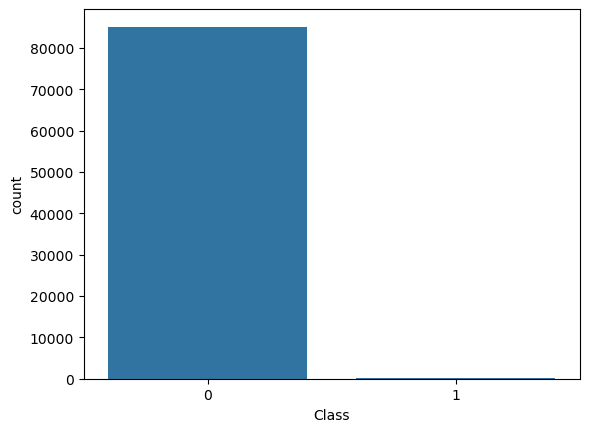

In [88]:
sns.countplot(x=data['Class'])

In [143]:
data['Class'].value_counts()

Class
0    85295
1      148
Name: count, dtype: int64

In [144]:
percent_0 = np.round((((data[data['Class'] == 0].shape[0] ) / len(data) ) * 100 ) , 2)
percent_1 = np.round((((data[data['Class'] == 1].shape[0] ) / len(data) ) * 100 ) , 2)

print("The % of class 0 is : {}% and of class 1 is : {}%".format(percent_0,percent_1))

The % of class 0 is : 99.83% and of class 1 is : 0.17%


In [91]:
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,127294.0,-2.537331,1.890864,-0.840555,-1.102759,-2.105725,0.367811,-2.737844,-3.543314,-0.483147,...,4.328165,-2.167329,1.022567,-0.241143,-1.094885,-0.475427,-0.177157,-0.082691,37.40,0
1,117632.0,-0.250839,1.104108,0.206089,0.417324,1.204079,-0.350694,1.369769,-0.133535,-0.957100,...,0.133048,0.499501,-0.392572,-0.393364,0.233354,-0.490717,0.143897,0.136810,9.27,0
2,148330.0,0.568980,-2.520416,-1.114138,1.670652,-1.128945,0.398822,0.190403,0.161493,0.840595,...,0.318037,-0.760732,-0.181332,0.595866,-0.760920,-1.048927,-0.096970,0.088686,700.00,0
3,67778.0,1.328892,0.226908,-0.308968,0.381772,0.238490,-0.282946,0.029460,-0.079962,0.227173,...,-0.379270,-1.148959,-0.047403,-1.074464,0.375683,0.182045,-0.031732,0.017501,14.99,0
4,6308.0,1.124863,-0.165691,1.337053,1.030033,-0.891116,0.202926,-0.825094,0.163280,2.301808,...,-0.216512,-0.195607,0.072785,0.045625,0.135192,0.308617,0.001142,0.017673,17.25,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85438,51279.0,-1.808185,1.328808,-0.991449,-2.473986,2.185095,3.496806,-1.030373,-1.860286,0.182992,...,-1.441887,-0.020080,0.256883,1.014602,-0.108679,0.672870,-0.701644,-0.338981,0.92,0
85439,28048.0,-0.442905,0.716727,1.256775,0.860048,1.210872,1.066390,0.888914,-0.176599,-0.172991,...,-0.154031,0.271637,-0.262547,-1.125678,0.019374,-0.233577,-0.013664,-0.274549,13.74,0
85440,125990.0,2.092418,-0.931315,-1.553089,-1.131369,-0.197801,-0.373117,-0.390388,-0.119017,-0.702381,...,-0.008183,-0.274004,0.214650,0.257477,-0.193262,-0.458271,-0.056360,-0.053928,74.00,0
85441,42168.0,1.293234,0.097565,-0.209304,0.329036,0.034958,-0.145507,-0.203271,0.153076,0.217831,...,-0.340111,-1.128741,0.000733,-0.956668,0.259784,0.158010,-0.044116,0.003539,1.98,0


In [145]:
scaler = StandardScaler()
data["Amount_scaled"] = scaler.fit_transform(data[["Amount"]])
data["Amount_scaled"] = scaler.transform(data[["Amount"]])

In [93]:
#splitting the data
from sklearn.model_selection import train_test_split
# split data and target 

X = data.drop("Class" , axis =1)
y = data["Class"]

X_train,X_test,y_train,y_test ,= train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [94]:
data["Amount_scaled"]

0       -0.209287
1       -0.324995
2        2.516211
3       -0.301467
4       -0.292171
           ...   
85438   -0.359342
85439   -0.306609
85440   -0.058739
85441   -0.354982
85442   -0.297724
Name: Amount_scaled, Length: 85309, dtype: float64

In [95]:
#random forest classifier
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100 , random_state=42)
model.fit(X_train, y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [126]:
predictions = model.predict(X)
probabilities = model.predict_proba(X)[:,1]
probabilities ,predictions


(array([0.  , 0.  , 0.01, ..., 0.  , 0.  , 0.  ], shape=(85309,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(85309,)))

In [127]:
data["Predicted_Class"] = predictions
data["Fraud_Probability"] = probabilities

In [150]:
#evaluate 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

[[25544     5]
 [    9    35]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25549
           1       0.88      0.80      0.83        44

    accuracy                           1.00     25593
   macro avg       0.94      0.90      0.92     25593
weighted avg       1.00      1.00      1.00     25593

ROC-AUC: 0.8976294215393592
